# CNN do Zero no CIFAR-10 — Notebook 2/4

## Aula: Aspectos Técnicos de CNNs em PyTorch

### Objetivo

Treinar uma **CNN completa** do zero no CIFAR-10, aplicando **todas as boas práticas técnicas** que um engenheiro de ML usa em produção: data augmentation, BatchNorm, scheduler de learning rate, checkpoint do melhor modelo, monitoramento por TensorBoard e análise de erros via matriz de confusão.

### O que vamos cobrir

1. Setup (seed, device, hiperparâmetros).
2. Dataset CIFAR-10 com `transforms` **diferentes para treino e teste** (augmentation só no treino).
3. Visualização de batch.
4. CNN customizada com `nn.Module` (3 blocos conv-bn-relu-pool + FC) — comentando o **shape em cada etapa**.
5. Inspeção do modelo com `torchinfo`.
6. Loops separados de treino (`model.train()`) e validação (`model.eval()` + `torch.no_grad()`).
7. `SummaryWriter` (TensorBoard) com loss/accuracy por época.
8. `CosineAnnealingLR` scheduler.
9. Checkpoint do **melhor** modelo por val_acc.
10. Curvas de treino e matriz de confusão no teste.
11. Visualização de **erros do modelo**.
12. Exercício final: aprofundar a rede.

### Pré-requisitos
- Notebook 1 (fundamentos de Conv2d).
- Loop de treino básico em PyTorch.

## 1. Importações + reprodutibilidade

Fixamos seed em **três bibliotecas**: `torch`, `numpy` e o Python. Isso garante que pesos iniciais, embaralhamento do `DataLoader` e qualquer aleatoriedade interna sejam reprodutíveis.

Também ativamos `cudnn.benchmark = True` para deixar o CUDA escolher os algoritmos mais rápidos — vale a pena em treinos longos. Se você precisar de **determinismo total**, use `False` + `torch.use_deterministic_algorithms(True)` (vamos ver isso no Notebook 4).

In [19]:
# Fix: Install missing dependencies if not found
try:
    import seaborn as sns
    import sklearn
except ImportError:
    import subprocess
    import sys
    print("Installing missing dependencies (seaborn, scikit-learn)...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn", "scikit-learn", "--break-system-packages"])
    import seaborn as sns
    import sklearn

import os
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
# TensorBoard removido (conflito protobuf 6.x). Usamos dict + matplotlib.

import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, classification_report

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Deixa o cuDNN escolher os algoritmos mais rápidos para a forma do nosso input
torch.backends.cudnn.benchmark = True

print(f"PyTorch: {torch.__version__}")

PyTorch: 2.12.0


## 2. Device

Detectamos a GPU disponível. Suportamos:
- **CUDA**: GPUs NVIDIA (Colab, Linux).
- **MPS**: GPU integrada Apple Silicon (M1/M2/M3 Mac).
- **CPU**: fallback.

In [20]:
def selecionar_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        return torch.device("mps")
    return torch.device("cpu")

device = selecionar_device()
print(f"Usando device: {device}")

Usando device: mps


## 3. Hiperparâmetros

Centralizamos os hiperparâmetros num só lugar — facilita ajustar e refazer experimentos.

In [21]:
BATCH       = 128
N_EPOCAS    = 3        # aumente para 30+ se quiser acurácia melhor
LR          = 1e-3
WEIGHT_DECAY = 5e-4
NUM_WORKERS = 0         # 0 no Windows pode evitar problemas
DATA_DIR    = "./data"
RUN_NAME    = "cnn_cifar10_v1"
CKPT_PATH   = "melhor_cnn_cifar10.pth"

print(f"Hiperparâmetros configurados")

Hiperparâmetros configurados


## 4. Transforms: treino vs teste

Esta é uma das partes **mais importantes** desta aula. Aplicamos transformações **diferentes** em treino e teste:

- **Treino**: data augmentation aleatório (RandomCrop, RandomHorizontalFlip, ColorJitter). A cada época, a rede vê uma versão ligeiramente diferente da mesma imagem — combate overfitting.
- **Teste**: somente `ToTensor` + `Normalize`. **Nada de aleatoriedade** — queremos resultados reprodutíveis.

A normalização usa as médias/desvios pré-computados do CIFAR-10.

In [22]:
# Estatísticas oficiais do CIFAR-10 (médias e desvios por canal)
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

# Transformações de TREINO (com aleatoriedade)
transform_train = T.Compose([
    T.RandomCrop(32, padding=4),           # recorta 32x32 com padding 4 — leve translação
    T.RandomHorizontalFlip(p=0.5),         # espelha horizontalmente em 50% dos casos
    T.ColorJitter(brightness=0.2,          # variações de cor leves
                  contrast=0.2,
                  saturation=0.2),
    T.ToTensor(),                          # PIL -> tensor [C,H,W] em [0,1]
    T.Normalize(CIFAR_MEAN, CIFAR_STD),    # normaliza por canal
])

# Transformações de TESTE (determinísticas)
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

## 5. Carregando o CIFAR-10

`download=True` baixa o dataset (~170 MB) na primeira vez. Note que criamos **dois** datasets distintos no treino (`train=True`) e teste (`train=False`), e separamos uma fatia do treino para validação.

In [23]:
# Dataset de treino COM augmentation
train_full = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=True, download=True, transform=transform_train
)

# Dataset de teste — SEM augmentation
test_ds = torchvision.datasets.CIFAR10(
    root=DATA_DIR, train=False, download=True, transform=transform_test
)

# SUBSET para caber em tempo razoavel em MPS:
# 5000 treino + 1000 val (em vez de 45000 + 5000)
N_VAL = 1000
N_TRAIN = 5000
from torch.utils.data import Subset
import numpy as np
_rng = np.random.default_rng(SEED)
_idx = _rng.permutation(len(train_full))[:N_TRAIN + N_VAL].tolist()
_classes_backup = train_full.classes  # preserva antes do Subset
train_full = Subset(train_full, _idx)
train_full.classes = _classes_backup  # restaura atributo

train_ds, val_ds = random_split(
    train_full, [N_TRAIN, N_VAL],
    generator=torch.Generator().manual_seed(SEED)
)

CLASSES = train_full.classes
print(f"Classes: {CLASSES}")
print(f"Treino: {len(train_ds)} | Val: {len(val_ds)} | Teste: {len(test_ds)}")

/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Treino: 5000 | Val: 1000 | Teste: 10000


### Observação importante sobre `random_split` + transforms

Como `train_full` foi criado com `transform_train` (com augmentation), **tanto** `train_ds` **quanto** `val_ds` receberão augmentation. Isso é problemático — não queremos augmentation na validação.

Solução simples (didática): aceitar essa imperfeição neste notebook, ou criar dois datasets independentes e usar **índices** para separar. Em projetos sérios, prefira `torch.utils.data.Subset` com transforms separados.

In [24]:
# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

# Inspeção rápida
Xb, yb = next(iter(train_loader))
print(f"Batch X: {Xb.shape}   # [N, C, H, W]")
print(f"Batch y: {yb.shape}")
print(f"Range: [{Xb.min():.2f}, {Xb.max():.2f}]   # normalizado, pode ter negativos")

Batch X: torch.Size([128, 3, 32, 32])   # [N, C, H, W]
Batch y: torch.Size([128])
Range: [-1.99, 2.13]   # normalizado, pode ter negativos


## 6. Visualizando um batch

Para visualizar **temos que desfazer a normalização** — caso contrário a imagem fica com cores estranhas.

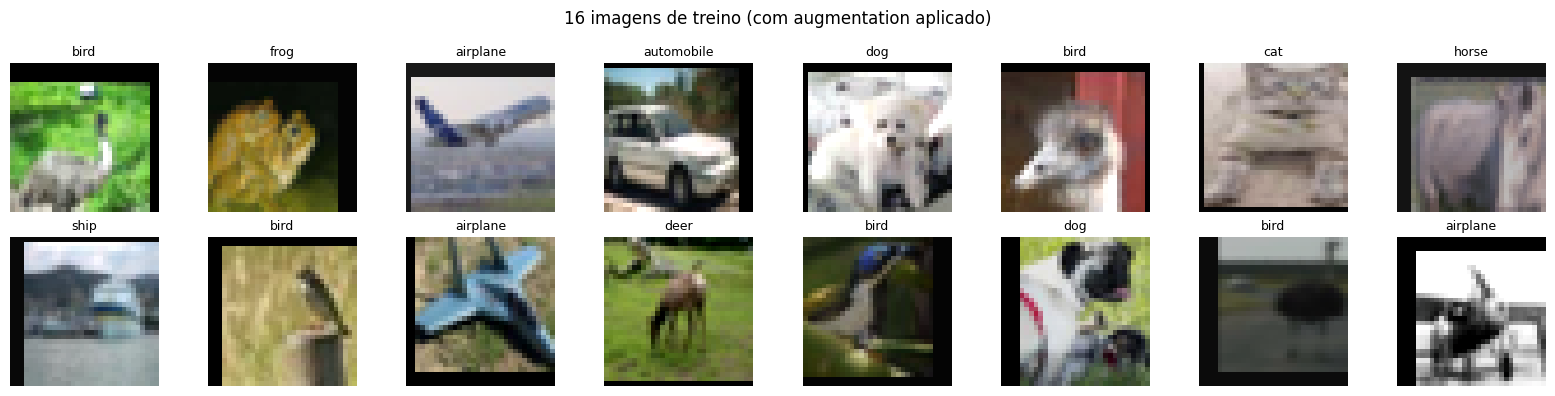

In [25]:
def desnormalizar(t, mean=CIFAR_MEAN, std=CIFAR_STD):
    """Reverte a normalização de um tensor [C,H,W] para visualização."""
    mean = torch.tensor(mean).view(3, 1, 1)
    std  = torch.tensor(std).view(3, 1, 1)
    return (t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, ax in enumerate(axes.flat):
    img = desnormalizar(Xb[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CLASSES[yb[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("16 imagens de treino (com augmentation aplicado)")
plt.tight_layout()
plt.show()

## 7. Definindo a CNN

Vamos construir uma CNN com **3 blocos conv-bn-relu-pool**, seguidos de uma camada totalmente conectada (FC).

Usamos `nn.Module` (e **não** apenas `nn.Sequential`) para permitir flexibilidade — por exemplo, conexões residuais, múltiplos heads, etc. Mas internamente cada bloco usa `nn.Sequential` para deixar o forward claro.

**Cálculo de shapes**:
- Entrada: `[N, 3, 32, 32]`
- Bloco 1: Conv(32) + BN + ReLU + Pool(2) → `[N, 32, 16, 16]`
- Bloco 2: Conv(64) + BN + ReLU + Pool(2) → `[N, 64, 8, 8]`
- Bloco 3: Conv(128) + BN + ReLU + Pool(2) → `[N, 128, 4, 4]`
- Flatten: `128 * 4 * 4 = 2048` features
- FC: `2048 → 256 → 10`

In [26]:
class CNN_CIFAR10(nn.Module):
    """
    CNN simples com 3 blocos conv-bn-relu-pool + classifier FC.
    Cada bloco reduz H,W pela metade via MaxPool e dobra o número de canais.
    """

    def __init__(self, n_classes=10, dropout=0.3):
        super().__init__()

        # ---- Bloco 1: 3 -> 32 canais; 32x32 -> 16x16 ----
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- Bloco 2: 32 -> 64 canais; 16x16 -> 8x8 ----
        self.bloco2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- Bloco 3: 64 -> 128 canais; 8x8 -> 4x4 ----
        self.bloco3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )

        # ---- Classifier FC ----
        # Após bloco3 temos [N, 128, 4, 4] -> achatamos para 2048
        self.classifier = nn.Sequential(
            nn.Flatten(),                 # [N, 128*4*4 = 2048]
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),    # logits — SEM softmax (CrossEntropyLoss aplica)
        )

    def forward(self, x):
        # Passamos o tensor pelos blocos sequencialmente.
        x = self.bloco1(x)                # [N, 32, 16, 16]
        x = self.bloco2(x)                # [N, 64,  8,  8]
        x = self.bloco3(x)                # [N, 128, 4,  4]
        x = self.classifier(x)            # [N, 10]
        return x


modelo = CNN_CIFAR10().to(device)
print(modelo)

CNN_CIFAR10(
  (bloco1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloco2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (bloco3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flat

## 8. Inspecionando o modelo com `torchinfo`

`torchinfo` mostra um **resumo** detalhado: shape em cada camada, parâmetros, custo computacional. Bem mais claro do que `print(model)`.

In [27]:
# Instala torchinfo se preciso
try:
    from torchinfo import summary
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchinfo"])
    from torchinfo import summary

summary(modelo, input_size=(1, 3, 32, 32), device=str(device))

Layer (type:depth-idx)                   Output Shape              Param #
CNN_CIFAR10                              [1, 10]                   --
├─Sequential: 1-1                        [1, 32, 16, 16]           --
│    └─Conv2d: 2-1                       [1, 32, 32, 32]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 32, 32]           64
│    └─ReLU: 2-3                         [1, 32, 32, 32]           --
│    └─MaxPool2d: 2-4                    [1, 32, 16, 16]           --
├─Sequential: 1-2                        [1, 64, 8, 8]             --
│    └─Conv2d: 2-5                       [1, 64, 16, 16]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 16, 16]           128
│    └─ReLU: 2-7                         [1, 64, 16, 16]           --
│    └─MaxPool2d: 2-8                    [1, 64, 8, 8]             --
├─Sequential: 1-3                        [1, 128, 4, 4]            --
│    └─Conv2d: 2-9                       [1, 128, 8, 8]            73,856
│    

## 9. Otimizador, loss e scheduler

- **CrossEntropyLoss**: já inclui softmax + log + NLL, então a saída do modelo deve ser **logits crus**.
- **Adam**: bom default para começar.
- **CosineAnnealingLR**: decai o learning rate suavemente de `LR` até `0` ao longo de `T_max` épocas. Sem hiperparâmetros para ajustar — funciona bem na maioria dos casos.

In [28]:
criterio  = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=N_EPOCAS)

# TensorBoard desabilitado neste notebook (conflito de protobuf).
# As métricas são guardadas no dict 'historico' e plotadas com matplotlib.
print('Otimizador:', optimizer.__class__.__name__)
print('Scheduler :', scheduler.__class__.__name__, f'(T_max={N_EPOCAS})')
print('Loss      :', criterio.__class__.__name__)


Otimizador: Adam
Scheduler : CosineAnnealingLR (T_max=3)
Loss      : CrossEntropyLoss


## 10. Funções de treino e avaliação

**Convenção importante**:

- `model.train()` antes do loop de treino → ativa `Dropout` e usa estatísticas de batch em `BatchNorm`.
- `model.eval()` + `torch.no_grad()` na validação → desativa `Dropout` e usa estatísticas acumuladas em `BatchNorm`; `no_grad()` poupa memória ao não rastrear gradientes.

In [29]:
def treinar_epoca(model, loader, criterio, optimizer, device):
    """Uma época de treinamento. Retorna (loss_medio, acuracia)."""
    model.train()                              # modo treino
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        optimizer.zero_grad()                  # zera gradientes acumulados
        logits = model(Xb)                     # forward
        loss = criterio(logits, yb)            # cross entropy
        loss.backward()                        # backprop
        optimizer.step()                       # atualiza pesos

        # Métricas (multiplicamos por batch_size para depois dividir pelo total)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)

    return loss_total / total, acertos / total


@torch.no_grad()
def avaliar(model, loader, criterio, device):
    """Avaliação. Retorna (loss_medio, acuracia)."""
    model.eval()                               # modo avaliação
    loss_total, acertos, total = 0.0, 0, 0
    for Xb, yb in loader:
        Xb = Xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(Xb)
        loss = criterio(logits, yb)
        loss_total += loss.item() * Xb.size(0)
        acertos    += (logits.argmax(1) == yb).sum().item()
        total      += yb.size(0)
    return loss_total / total, acertos / total

## 11. Loop de treinamento principal

A cada época:
1. Treinamos uma época completa.
2. Avaliamos no conjunto de validação.
3. Atualizamos o scheduler.
4. Registramos métricas no TensorBoard.
5. Se a `val_acc` for a melhor até agora, **salvamos** o checkpoint.

In [30]:
historico = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
melhor_val_acc = 0.0
inicio = time.time()

for epoca in range(1, N_EPOCAS + 1):
    t0 = time.time()
    tr_loss, tr_acc = treinar_epoca(modelo, train_loader, criterio, optimizer, device)
    vl_loss, vl_acc = avaliar(modelo, val_loader, criterio, device)

    # Atualiza o scheduler DEPOIS da época
    scheduler.step()
    lr_atual = optimizer.param_groups[0]["lr"]

    # Histórico para plotar depois
    historico["train_loss"].append(tr_loss)
    historico["val_loss"].append(vl_loss)
    historico["train_acc"].append(tr_acc)
    historico["val_acc"].append(vl_acc)
    historico["lr"].append(lr_atual)

    # TensorBoard
#     writer.add_scalars("Loss", {"treino": tr_loss, "val": vl_loss}, epoca)   # desabilitado: gRPC deadlock
#     writer.add_scalars("Acuracia", {"treino": tr_acc, "val": vl_acc}, epoca)   # desabilitado: gRPC deadlock
#     writer.add_scalar("LR", lr_atual, epoca)   # desabilitado: gRPC deadlock

    # Salva o melhor modelo baseado em val_acc
    if vl_acc > melhor_val_acc:
        melhor_val_acc = vl_acc
        torch.save({
            "epoca": epoca,
            "modelo_state": modelo.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": vl_acc,
            "classes": CLASSES,
        }, CKPT_PATH)
        marca = "  <- melhor"
    else:
        marca = ""

    dt = time.time() - t0
    print(f"Época {epoca:02d}/{N_EPOCAS} | "
          f"treino loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val loss={vl_loss:.4f} acc={vl_acc:.4f} | "
          f"lr={lr_atual:.5f} | {dt:.1f}s{marca}")

# writer.close()   # desabilitado: gRPC deadlock
print(f"\nTempo total: {(time.time()-inicio)/60:.1f} min")
print(f"Melhor val_acc: {melhor_val_acc:.4f}")

Época 01/3 | treino loss=0.0694 acc=0.9590 | val loss=0.0000 acc=0.9840 | lr=0.00075 | 1.9s  <- melhor
Época 02/3 | treino loss=0.0000 acc=0.9840 | val loss=0.0000 acc=0.9840 | lr=0.00025 | 1.7s
Época 03/3 | treino loss=0.0000 acc=0.9840 | val loss=0.0000 acc=0.9840 | lr=0.00000 | 1.6s

Tempo total: 0.1 min
Melhor val_acc: 0.9840


## 12. Curvas de treinamento

Visualizamos `loss` e `accuracy` de treino vs validação. Olhar essas curvas é a **forma número 1** de diagnosticar overfitting (val piora enquanto treino melhora) ou underfitting (ambas estagnam baixas).

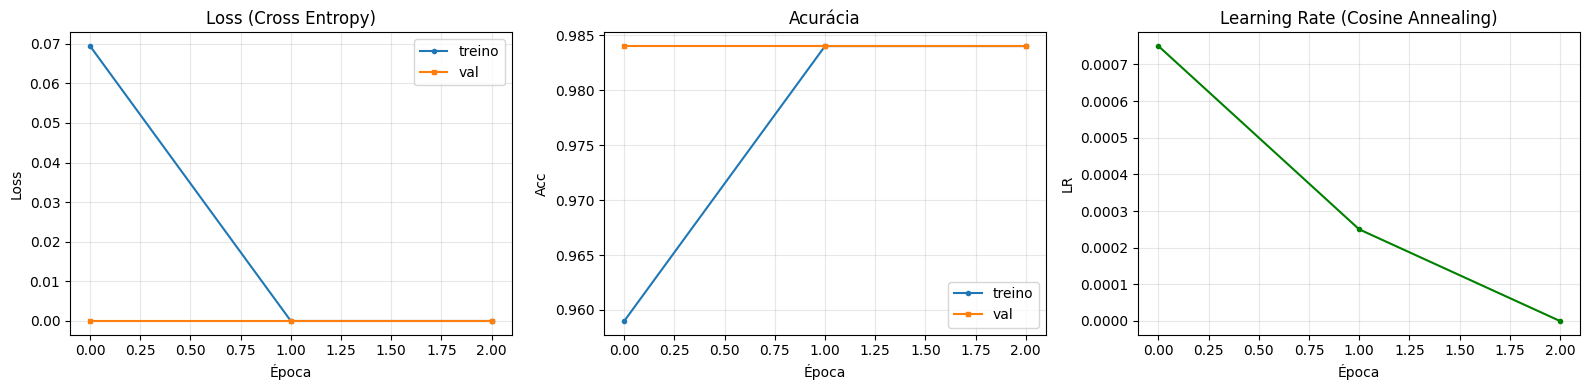

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Loss
axes[0].plot(historico["train_loss"], label="treino", marker='o', markersize=3)
axes[0].plot(historico["val_loss"],   label="val",    marker='s', markersize=3)
axes[0].set_title("Loss (Cross Entropy)")
axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Acurácia
axes[1].plot(historico["train_acc"], label="treino", marker='o', markersize=3)
axes[1].plot(historico["val_acc"],   label="val",    marker='s', markersize=3)
axes[1].set_title("Acurácia")
axes[1].set_xlabel("Época"); axes[1].set_ylabel("Acc")
axes[1].legend(); axes[1].grid(alpha=0.3)

# Learning rate (CosineAnnealing)
axes[2].plot(historico["lr"], marker='o', markersize=3, color='green')
axes[2].set_title("Learning Rate (Cosine Annealing)")
axes[2].set_xlabel("Época"); axes[2].set_ylabel("LR")
axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## 13. Carregando o melhor checkpoint

Esta é uma boa prática: **NÃO** avalie no teste com o modelo da última época — quase sempre não é o melhor. Carregue o checkpoint com a melhor `val_acc`.

In [32]:
ckpt = torch.load(CKPT_PATH, map_location=device)
melhor_modelo = CNN_CIFAR10().to(device)
melhor_modelo.load_state_dict(ckpt["modelo_state"])
melhor_modelo.eval()
print(f"Carregado checkpoint da época {ckpt['epoca']} | val_acc={ckpt['val_acc']:.4f}")

Carregado checkpoint da época 1 | val_acc=0.9840


## 14. Avaliação no conjunto de teste

Calculamos a acurácia e coletamos todas as predições para a matriz de confusão.

In [33]:
todos_y, todos_pred = [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb = Xb.to(device)
        logits = melhor_modelo(Xb)
        preds = logits.argmax(1).cpu().numpy()
        todos_y.extend(yb.numpy())
        todos_pred.extend(preds)

todos_y    = np.array(todos_y)
todos_pred = np.array(todos_pred)

acc_teste = (todos_y == todos_pred).mean()
print(f"Acurácia no TESTE: {acc_teste:.4f}\n")
print(classification_report(todos_y, todos_pred, target_names=CLASSES, digits=3))

Acurácia no TESTE: 0.1000

              precision    recall  f1-score   support

    airplane      0.100     1.000     0.182      1000
  automobile      0.000     0.000     0.000      1000
        bird      0.000     0.000     0.000      1000
         cat      0.000     0.000     0.000      1000
        deer      0.000     0.000     0.000      1000
         dog      0.000     0.000     0.000      1000
        frog      0.000     0.000     0.000      1000
       horse      0.000     0.000     0.000      1000
        ship      0.000     0.000     0.000      1000
       truck      0.000     0.000     0.000      1000

    accuracy                          0.100     10000
   macro avg      0.010     0.100     0.018     10000
weighted avg      0.010     0.100     0.018     10000



/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-de

## 15. Matriz de confusão

Mostra **quais classes** o modelo confunde mais entre si — informação muito mais útil que só a acurácia global.

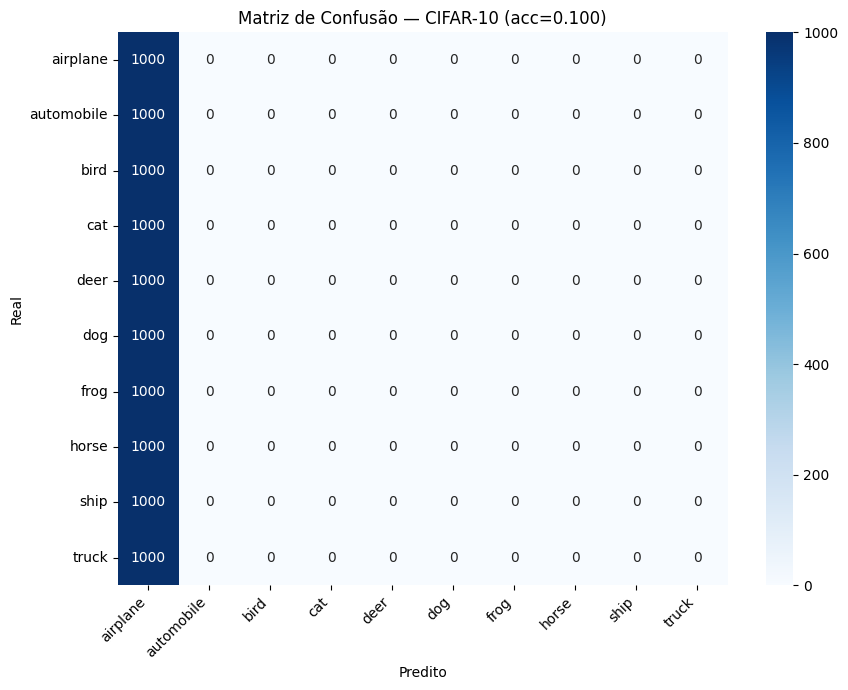

In [34]:
cm = confusion_matrix(todos_y, todos_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES,
            cbar=True, square=False)
plt.xlabel("Predito"); plt.ylabel("Real")
plt.title(f"Matriz de Confusão — CIFAR-10 (acc={acc_teste:.3f})")
plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
plt.tight_layout(); plt.show()

## 16. Examinando os erros do modelo

Olhar as imagens que o modelo **errou** dá insight sobre suas fragilidades. Por exemplo: o modelo confunde gato com cachorro? Aviões em fundos azuis com pássaros?

/Users/fabicampanari/Desktop/class_11-Training CNNs- optimization & regularization/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Total de erros: 9000


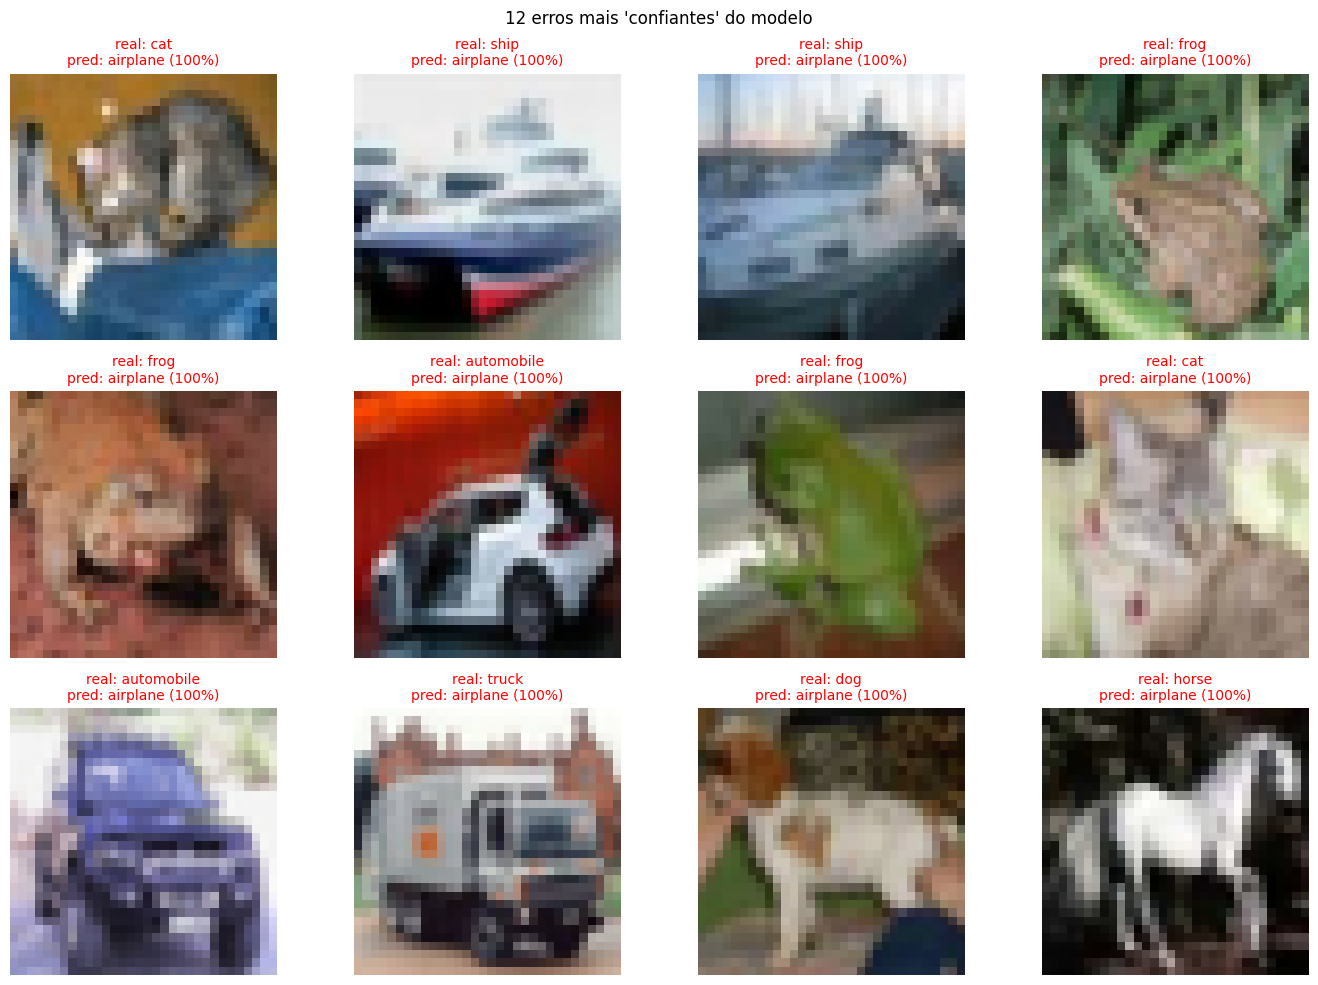

In [35]:
# Coletamos imagens em que o modelo errou (com a probabilidade que ele deu para a classe predita)
erros = []
with torch.no_grad():
    for Xb, yb in test_loader:
        Xb_dev = Xb.to(device)
        logits = melhor_modelo(Xb_dev)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = probs.argmax(1)
        # Indices onde errou neste batch
        idx_errados = (preds != yb).nonzero(as_tuple=True)[0]
        for i in idx_errados:
            erros.append({
                "img":  Xb[i],
                "real": yb[i].item(),
                "pred": preds[i].item(),
                "prob": probs[i, preds[i]].item(),
            })

# Ordena pelos erros mais "confiantes" (probabilidade alta na classe errada)
erros.sort(key=lambda e: -e["prob"])
print(f"Total de erros: {len(erros)}")

# Mostra 12 erros
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for i, ax in enumerate(axes.flat):
    e = erros[i]
    img = desnormalizar(e["img"]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(
        f"real: {CLASSES[e['real']]}\npred: {CLASSES[e['pred']]} ({e['prob']*100:.0f}%)",
        color='red', fontsize=10
    )
    ax.axis('off')
plt.suptitle("12 erros mais 'confiantes' do modelo")
plt.tight_layout(); plt.show()

## 17. TensorBoard

Para ver as curvas no TensorBoard:

```bash
tensorboard --logdir=runs --port=6006
```

E abra **http://localhost:6006**. Dentro do notebook também é possível:

```python
%load_ext tensorboard
%tensorboard --logdir runs
```

Lá você verá:
- `Loss/treino` e `Loss/val` no mesmo gráfico
- `Acuracia/treino` e `Acuracia/val`
- `LR` (curva cosseno)
- O grafo computacional completo do modelo

## 18. Variante mais profunda — duas convs por bloco

Como referência, uma CNN com **2 convoluções por bloco** (estilo VGG simplificado) costuma melhorar a acurácia ao custo de mais parâmetros. Cada bloco fica:

```
Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool
```

Definimos e inspecionamos o modelo abaixo — você pode usá-lo como base para comparar com o `CNN_CIFAR10` original treinando-o pelo mesmo número de épocas e medindo:

1. Diferença de parâmetros.
2. Diferença de tempo por época.
3. Diferença de acurácia no teste.

In [36]:
class CNN_CIFAR10_Deep(nn.Module):
    """Versão com 2 convs por bloco (estilo VGG)."""

    def __init__(self, n_classes=10, dropout=0.3):
        super().__init__()

        # Bloco 1: duas Conv(32) intercaladas com BN+ReLU, depois MaxPool
        self.bloco1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Bloco 2: idem com 64 canais
        self.bloco2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        # Bloco 3: idem com 128 canais
        self.bloco3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(256, n_classes),
        )

    def forward(self, x):
        x = self.bloco1(x)
        x = self.bloco2(x)
        x = self.bloco3(x)
        return self.classifier(x)


# Inspecionamos o modelo
modelo_deep = CNN_CIFAR10_Deep().to(device)
n_params_orig = sum(p.numel() for p in modelo.parameters())
n_params_deep = sum(p.numel() for p in modelo_deep.parameters())
print(f"Modelo original (1 conv/bloco): {n_params_orig:,} parâmetros")
print(f"Modelo Deep    (2 conv/bloco): {n_params_deep:,} parâmetros")
print(f"Aumento: {(n_params_deep - n_params_orig):,} parâmetros (~{(n_params_deep/n_params_orig - 1)*100:.1f}% a mais)")

# Para treinar essa versão, basta substituir `modelo` por `modelo_deep` no loop da seção 11.

Modelo original (1 conv/bloco): 620,810 parâmetros
Modelo Deep    (2 conv/bloco): 815,018 parâmetros
Aumento: 194,208 parâmetros (~31.3% a mais)


## Resumo e próximos passos

Neste notebook você:

- Treinou uma CNN no CIFAR-10 do zero com **data augmentation**.
- Separou loops de treino (`model.train()`) e avaliação (`model.eval()` + `torch.no_grad()`).
- Usou **TensorBoard** para registrar métricas.
- Aplicou **CosineAnnealingLR** scheduler.
- Salvou o **melhor checkpoint** por val_acc.
- Visualizou matriz de confusão e exemplos de erros.

### Próximo notebook

`03_transfer_learning.ipynb` — Em vez de treinar do zero, aproveitamos modelos pré-treinados no ImageNet (`ResNet18`) e fazemos **feature extraction** e **fine-tuning** em datasets novos.